# Part4: Detect the MI cascade in the HGSC dataset

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import re
import os

In [2]:
def build_hyper_edge_adj(edge_index_cur, num_edges):
    # edge_index_cur: shape [num_edges, 2], 每行是 (src, tgt)
    src = edge_index_cur[:, 0]
    tgt = edge_index_cur[:, 1]

    # 构造 (row, col)，row 是当前边索引，col 是“其他边”的索引
    # 条件：src[j] == tgt[i]
    # 这等价于：对所有 tgt[i]，找到 src == tgt[i] 的边 j

    # 建立 mapping: tgt_value -> 所有 j (src[j] == tgt_value)
    from collections import defaultdict
    tgt2rows = defaultdict(list)
    for j, s in enumerate(src):
        tgt2rows[s].append(j)

    rows, cols = [], []
    for i, t in enumerate(tgt):
        if t in tgt2rows:
            rows.extend([i] * len(tgt2rows[t]))
            cols.extend(tgt2rows[t])

    data = np.ones(len(rows), dtype=np.int8)
    hyper_edge_adj = csr_matrix((data, (rows, cols)), shape=(num_edges, num_edges))

    return hyper_edge_adj

def fdr_correct_pvals(pvals, alpha=0.05):
    d = pvals.shape[0]
    flat_pvals = pvals.flatten()
    reject, pvals_fdr = fdrcorrection(flat_pvals, alpha=alpha, method='indep')
    # reject, pvals_fdr = fdrcorrection(flat_pvals, alpha=alpha, method='negcorr')
    return reject.reshape(d, d), pvals_fdr.reshape(d, d)

def compute_observed_colocalization(F, A, MI_threshold):
    """Compute observed colocalization count matrix for one sample."""
    F_cut = np.where(F > MI_threshold, 1, 0)
    AF = A @ F_cut
    colocal_count_cur = F_cut.T @ AF
    return F_cut, colocal_count_cur

def get_celltype_pairs(edge_index_cur, adata_cur):
    """Get indices of edges grouped by cell-type pairs."""
    ct_edge_index_cur = adata_cur.obs['cell.types'].values[edge_index_cur]
    ct_pairs = [tuple(row) for row in ct_edge_index_cur]
    unique_pairs = {pair: np.where([p == pair for p in ct_pairs])[0] for pair in set(ct_pairs)}
    return unique_pairs


def compute_permutation_colocalization(F_cut, A, unique_pairs, nperm=100):
    """Permutation test: shuffle F_cut within each cell-type pair group."""
    colocal_count_perm_list = []
    for _ in range(nperm):
        F_cut_perm = np.empty_like(F_cut)
        for idx in unique_pairs.values():
            shuffled_idx = np.random.permutation(idx)
            F_cut_perm[idx, :] = F_cut[shuffled_idx, :]
        AF_perm = A @ F_cut_perm
        colocal_count_perm_cur = F_cut_perm.T @ AF_perm
        colocal_count_perm_list.append(colocal_count_perm_cur)

    return np.stack(colocal_count_perm_list, axis=0)  # (nperm, d, d)


def compute_statistics(colocal_count_cur, colocal_count_perm_array):
    """Compute z-score-like ratio and permutation-based p-values."""
    count_matrix = np.sum(colocal_count_cur[None, :, :] > colocal_count_perm_array, axis=0)
    colocal_count_ratio_cur = (colocal_count_cur - colocal_count_perm_array.mean(axis=0)) / (
        colocal_count_perm_array.std(axis=0) + 1e-8
    )
    pvalue_matrix = 1 - count_matrix / colocal_count_perm_array.shape[0]
    return colocal_count_ratio_cur, pvalue_matrix


def plot_example_density(colocal_count_perm_array, colocal_count_cur, file_savepath_main,
                         index_show=2, columns_show=3):
    """Plot the permutation distribution vs. observed count for visualization."""
    colocal_perm_vec_show = colocal_count_perm_array[:, index_show, columns_show]
    colocal_count_cur_show = colocal_count_cur[index_show, columns_show]

    plt.figure(figsize=(4, 4))
    sns.kdeplot(colocal_perm_vec_show, fill=True, color="skyblue", alpha=0.6, label="Permutation distribution")
    plt.axvline(colocal_count_cur_show, color="red", linestyle="--", lw=2,
                label=f"Observed = {colocal_count_cur_show}")
    plt.xlabel("MI cascade count")
    plt.ylabel("Density")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(file_savepath_main + "/Colocal_perm_density.png", dpi=300)
    plt.close()

def fdr_correct_pvals(pvals, alpha=0.05):
    """Simple Benjamini–Hochberg FDR correction."""
    pvals_flat = pvals.flatten()
    n = len(pvals_flat)
    order = np.argsort(pvals_flat)
    ranked_pvals = pvals_flat[order]
    adj_pvals = ranked_pvals * n / (np.arange(1, n + 1))
    adj_pvals = np.minimum.accumulate(adj_pvals[::-1])[::-1]
    adj_pvals = np.clip(adj_pvals, 0, 1)
    reject = adj_pvals < alpha
    adj_matrix = np.zeros_like(pvals_flat)
    adj_matrix[order] = adj_pvals
    return reject.reshape(pvals.shape), adj_matrix.reshape(pvals.shape)


# Paths

In [3]:
file_savepath_main = "D:/CellFlowMap/HGSC/Results/V1/SpiderNet_Result_Mode_cell_class_selfsetdim15/"
Factor_envir_list_path = file_savepath_main + f"Factor_envir_list.pkl"
SpiderNet_data_pyg_list_path = file_savepath_main + f"SpiderNet_data_pyg_list.pkl"
adata_list_path = file_savepath_main + f"adata_list.pkl"

# Load data

In [4]:
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)
SpiderNet_data_pyg_list = pd.read_pickle(SpiderNet_data_pyg_list_path)
adata_list = pd.read_pickle(adata_list_path)
samples_name_list = [np.unique(adata_list[i].obs['samples'])[0] for i in range(len(adata_list))]

# Count the number of colocalization MI edge pairs along with permutation test

In [5]:
Factor_envir_all = np.concatenate(Factor_envir_list, axis=0)
Factor_envir_all_max = np.max(Factor_envir_all, axis=0)
Factor_envir_norm_list = [F / (Factor_envir_all_max + 1e-8) for F in Factor_envir_list]
Factor_envir_norm_all = np.concatenate(Factor_envir_norm_list, axis=0)

nsample = len(SpiderNet_data_pyg_list)
d = Factor_envir_list[0].shape[1]

MI_threshold = 0.7
nperm = 100

## =========================================
## Precompute adjacency list
## =========================================
hyper_edge_adj_list = []
for sample_index in range(nsample):
    edge_index_cur = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
    A = build_hyper_edge_adj(edge_index_cur, edge_index_cur.shape[0])  # csr_matrix
    hyper_edge_adj_list.append(A)
## =========================================
colocal_count_list = []
colocal_count_perm_array_list = []
colocal_count_ratio_list = []
pvalue_matrix_list = []

for sample_index in range(nsample):
    if sample_index % 5 == 0:
        print(f"Processing ratio: {sample_index / nsample:.2f}")

    F = Factor_envir_norm_list[sample_index]
    A = hyper_edge_adj_list[sample_index]
    adata_cur = adata_list[sample_index]
    edge_index_cur = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()

    # --- Observed colocalization ---
    F_cut, colocal_count_cur = compute_observed_colocalization(F, A, MI_threshold)
    colocal_count_list.append(colocal_count_cur)

    # --- Permutation ---
    unique_pairs = get_celltype_pairs(edge_index_cur, adata_cur)
    colocal_count_perm_array = compute_permutation_colocalization(F_cut, A, unique_pairs, nperm)
    colocal_count_perm_array_list.append(colocal_count_perm_array)

    # --- Statistics ---
    colocal_count_ratio_cur, pvalue_matrix = compute_statistics(colocal_count_cur, colocal_count_perm_array)
    colocal_count_ratio_list.append(colocal_count_ratio_cur)
    pvalue_matrix_list.append(pvalue_matrix)


## =========================================
# === Merge observed and permutation results ===
colocal_count_merge = np.stack(colocal_count_list, axis=0)             # (nsample, d, d)
colocal_count_merge_sum = colocal_count_merge.sum(axis=0)              # (d, d)

colocal_count_perm_array_merge = np.stack(colocal_count_perm_array_list, axis=0)  # (nsample, nperm, d, d)
colocal_count_perm_array_merge_sum = colocal_count_perm_array_merge.sum(axis=0)   # (nperm, d, d)

# === Z-score-like normalization ===
colocal_count_merge_sum_zscore = colocal_count_merge_sum / (colocal_count_perm_array_merge_sum.mean(axis=0) + 1e-8)
colocal_count_merge_sum_zscore = np.log2(colocal_count_merge_sum_zscore + 1e-3)

# === P-value estimation ===
colocal_count_merge_sum_pvalue = 1 - np.mean(
    colocal_count_merge_sum[None, :, :] > colocal_count_perm_array_merge_sum, axis=0
)
colocal_count_merge_sum_pvalue[colocal_count_merge_sum_pvalue < 1e-8] = 1e-5

# === Convert to DataFrame ===
mi_labels = [f"MI-{i}" for i in range(1, d + 1)]
colocal_count_merge_sum_zscore = pd.DataFrame(colocal_count_merge_sum_zscore, index=mi_labels, columns=mi_labels)
colocal_count_merge_sum_pvalue = pd.DataFrame(colocal_count_merge_sum_pvalue, index=mi_labels, columns=mi_labels)

# === FDR correction ===
reject_cur, pvals_fdr_cur = fdr_correct_pvals(colocal_count_merge_sum_pvalue.values, alpha=0.05)
colocal_count_merge_sum_pvalue = pd.DataFrame(pvals_fdr_cur, index=mi_labels, columns=mi_labels)

# === Summary ===
sig_count = np.sum(
    (colocal_count_merge_sum_pvalue.values < 1e-3)
    * (colocal_count_merge_sum_zscore.values > np.log2(1.5))
)
print(f"Significant MI-MI co-localizations: {sig_count}")

Processing ratio: 0.00
Processing ratio: 0.10
Processing ratio: 0.21
Processing ratio: 0.31
Processing ratio: 0.42
Processing ratio: 0.52
Processing ratio: 0.62
Processing ratio: 0.73
Processing ratio: 0.83
Processing ratio: 0.94
Significant MI-MI co-localizations: 20


## Hierarchical clustering heatmap of MI-MI colocalization Z-scores

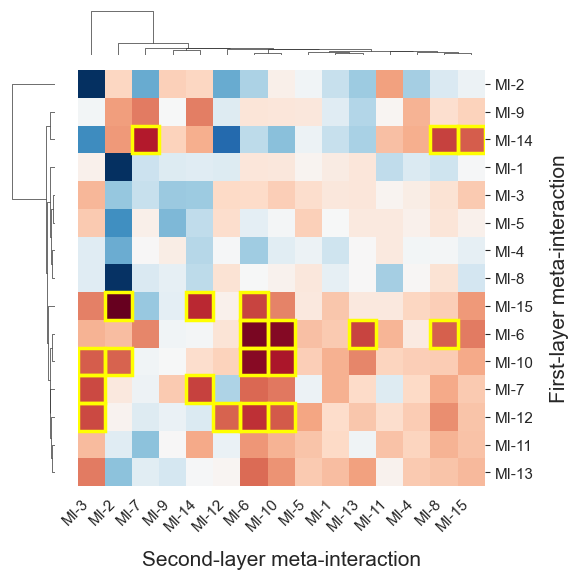

✅ Heatmap saved to: D:/CellFlowMap/HGSC/Results/V1/SpiderNet_Result_Mode_cell_class_selfsetdim15//Heatmap_Zscore_Colocalization_Count_allsample.png


In [6]:
# =========================================
# Hierarchical clustering heatmap
# =========================================
g = sns.clustermap(
    colocal_count_merge_sum_zscore,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,                   # enhance contrast range
    figsize=(7, 6),
    square=False,                      # True makes text cramped
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=None,                     # hide color bar for cleaner layout
)

# =========================================
# Retrieve clustered row/column order
# =========================================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# =========================================
# Highlight significant MI-MI pairs 
# (p < 1e-3 and Zscore > log2(1.5))
# =========================================
for i_new, i_old in enumerate(row_order):
    for j_new, j_old in enumerate(col_order):
        p_val = colocal_count_merge_sum_pvalue.iloc[i_old, j_old]
        z_val = colocal_count_merge_sum_zscore.iloc[i_old, j_old]
        if p_val < 1e-3 and z_val > np.log2(1.5):
            g.ax_heatmap.add_patch(
                Rectangle(
                    (j_new, i_new),
                    1, 1,
                    fill=False,
                    edgecolor="yellow",
                    lw=2.5
                )
            )

# =========================================
# Axis labels and tick style
# =========================================
g.ax_heatmap.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
g.ax_heatmap.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)

# Adjust tick labels orientation and font
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45, ha="right", fontsize=11
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0, fontsize=11
)

# =========================================
# Layout and save
# =========================================
g.fig.tight_layout()
g.fig.subplots_adjust(bottom=0.18, left=0.18)   # add margins to avoid label clipping

out_path = file_savepath_main + "/Heatmap_Zscore_Colocalization_Count_allsample.png"
g.fig.savefig(out_path, dpi=300)
plt.show()
plt.close()

print(f"✅ Heatmap saved to: {out_path}")


## Summary the MI colocalization test results

In [7]:
MI_colocal_summary = pd.DataFrame({
    "zscore_countcolocal": np.array(colocal_count_merge_sum_zscore).flatten(),
    "pvalue_adjusted": np.array(colocal_count_merge_sum_pvalue).flatten(),
    "MI_first": np.repeat(np.arange(1, d + 1), d),
    "MI_second": np.tile(np.arange(1, d + 1), d)
})
MI_colocal_summary_significant = MI_colocal_summary.loc[(MI_colocal_summary['zscore_countcolocal'] > np.log2(1.5)) & (MI_colocal_summary['pvalue_adjusted'] < 0.001),:]

# Enriched Celltype Triple Summary and Visualization

In [8]:
# ==============================================================
# 1. Initialize containers for results
# --------------------------------------------------------------
# These lists will store per-MI-pair results for later merging.
# ==============================================================
summary_table_choose_df_list = []
celltriple_index_sample_list = []
prop_avg_allsample_filter_list = []


# ==============================================================
# 2. Loop over significant MI pairs
# --------------------------------------------------------------
# For each (MI_first, MI_second) pair, compute how often two
# meta-interactions co-occur through specific celltype triples.
# ==============================================================
for idx in range(MI_colocal_summary_significant.shape[0]):
    MI_first = int(MI_colocal_summary_significant.iloc[idx]["MI_first"])
    MI_second = int(MI_colocal_summary_significant.iloc[idx]["MI_second"])
    MI_first_idx, MI_second_idx = MI_first - 1, MI_second - 1
    MI_first_name, MI_second_name = f"MI-{MI_first}", f"MI-{MI_second}"

    all_summary_tables = []
    celltriple_index_all = []


    # ==============================================================
    # 2.1 Compute celltype triples for each sample
    # --------------------------------------------------------------
    # Identify triplets (cell1 → cell2 → cell3) connected via
    # MI_first and MI_second within each sample.
    # ==============================================================
    for sample_index in range(nsample):
        F = Factor_envir_norm_list[sample_index]  # (E, d)
        A = hyper_edge_adj_list[sample_index]     # (E, E) sparse adjacency
        edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
        adata_cur = adata_list[sample_index]
        celltypes = adata_cur.obs['cell.types'].values[edge_index]
        F_cut = (F > MI_threshold).astype(int)

        # --- select edges with active MIs ---
        rel_first = np.where(F_cut[:, MI_first_idx])[0]
        rel_second = np.where(F_cut[:, MI_second_idx])[0]
        A_sub = A[rel_first, :][:, rel_second].toarray()

        # --- identify overlapping edges ---
        a_i, a_j = np.where(A_sub == 1)
        paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

        # --- construct cell-type triples ---
        pair_first = edge_index[paired_idx[:, 0], :]
        pair_second = edge_index[paired_idx[:, 1], :]
        celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
        celltriple_index_all.append(celltriple_index)

        triple_ct = adata_cur.obs['cell.types'].values[celltriple_index]
        triple_label = triple_ct[:, 0] + " -> " + triple_ct[:, 1] + " -> " + triple_ct[:, 2]

        # --- summarize unique triples and their counts ---
        triple_counts = pd.Series(triple_label).value_counts().reset_index()
        triple_counts.columns = ["Celltype_triple", "Count"]
        if triple_counts.empty:
            continue

        # --- derive sub-relationships and metadata ---
        parts = triple_counts["Celltype_triple"].str.split("->", expand=True)
        triple_counts["ctp_MI_first"] = parts[0].str.strip() + " -> " + parts[1].str.strip()
        triple_counts["ctp_MI_second"] = parts[1].str.strip() + " -> " + parts[2].str.strip()
        triple_counts["Sample"] = adata_cur.obs["samples"].unique()[0]

        # --- compute within-sample proportion and adjusted ratio ---
        triple_counts["prop"] = triple_counts["Count"] / triple_counts["Count"].sum()

        def calc_ratio(row):
            ctp1, ctp2, cnt = row["ctp_MI_first"], row["ctp_MI_second"], row["Count"]
            ct1a, ct1b = ctp1.split(" -> ")
            ct2a, ct2b = ctp2.split(" -> ")
            edge_ct = celltypes
            r1 = np.sum((edge_ct[:, 0] == ct1a) & (edge_ct[:, 1] == ct1b))
            r2 = np.sum((edge_ct[:, 0] == ct2a) & (edge_ct[:, 1] == ct2b))
            denom = (float(r1) * float(r2)) / float(F_cut.shape[0])
            return float(cnt) / denom if denom > 0 else np.nan

        triple_counts["ratio"] = triple_counts.apply(calc_ratio, axis=1)
        all_summary_tables.append(triple_counts)


    # ==============================================================
    # 2.2 Merge across all samples for this MI pair
    # --------------------------------------------------------------
    # Combine triplet counts, compute average proportions, and store.
    # ==============================================================
    celltriple_index_sample_list.append(celltriple_index_all)
    combined = pd.concat(all_summary_tables, axis=0)
    total_count = combined["Count"].sum()

    prop_avg = (
        combined.groupby("Celltype_triple")["Count"]
        .sum()
        .div(total_count)
        .reset_index(name="prop_avg_allsample")
    )
    prop_avg["MI_first"], prop_avg["MI_second"] = MI_first, MI_second
    prop_avg_allsample_filter_list.append(prop_avg)

# 3. Aggregate results across all MI pairs
# --------------------------------------------------------------
# Combine triple-level results and create a pivot table showing
# which triples dominate in which MI cascades.
# ==============================================================
prop_avg_allsample_filter_merge = pd.concat(prop_avg_allsample_filter_list, axis=0)
prop_avg_allsample_filter_merge["MI cascade"] = (
    "MI-" + prop_avg_allsample_filter_merge["MI_first"].astype(str)
    + " -> MI-" + prop_avg_allsample_filter_merge["MI_second"].astype(str)
)

pivot = prop_avg_allsample_filter_merge.pivot(
    index="Celltype_triple", columns="MI cascade", values="prop_avg_allsample"
).fillna(0)

prop_avg_allsample_filter_merge_pivot_select = pivot.loc[pivot.max(axis=1) > 0.1, :]

print("✅ Summary completed.")
print(f"Selected pivot shape: {prop_avg_allsample_filter_merge_pivot_select.shape}")

✅ Summary completed.
Selected pivot shape: (14, 20)


## Visualization: Celltype Triple × MI Cascade Heatmaps

In [9]:
def plot_heatmap(data, title, xlabel, ylabel, filename, highlight_malignant=False):
    """Plot clustered heatmap for triple × MI cascade proportion."""
    # --- determine figure size dynamically ---
    fig_w = max(6, 0.6 * data.shape[0]) * 0.8
    fig_h = max(6, 0.5 * data.shape[1])
    
    # --- create clustermap ---
    g = sns.clustermap(
        data.T,
        cmap="Reds",
        vmin=0, vmax=0.5,
        figsize=(fig_w, fig_h),
        square=False,
        row_cluster=True, col_cluster=True,
        dendrogram_ratio=(0.1, 0.1),
        cbar_pos=None,
        linecolor="lightgrey", linewidth=0.5
    )

    # --- hide dendrograms ---
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)

    # --- axis labels ---
    g.ax_heatmap.set_xlabel(xlabel, fontsize=14)
    g.ax_heatmap.set_ylabel(ylabel, fontsize=14)
    g.ax_heatmap.set_title(title, fontsize=16, pad=12)

    # --- highlight "Malignant" triples in x-axis if required ---
    xticklabels = g.ax_heatmap.get_xticklabels()
    for label in xticklabels:
        label_text = label.get_text()
        label.set_color("red" if ("Malignant" in label_text and highlight_malignant) else "black")

    # --- format tick labels ---
    g.ax_heatmap.set_xticklabels(xticklabels, rotation=60, ha="right", fontsize=11)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)

    # --- layout & save ---
    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.25, left=0.25)
    g.fig.savefig(file_savepath_main + "/" + filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved: {filename}")
    

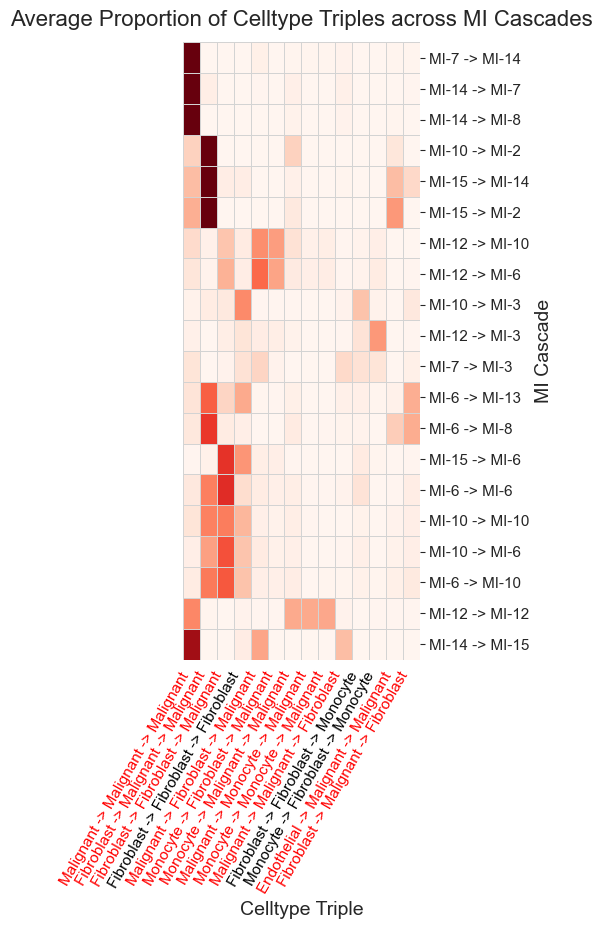

✅ Saved: Heatmap_Average_prop_Celltype_triple_across_MI_cascades.png


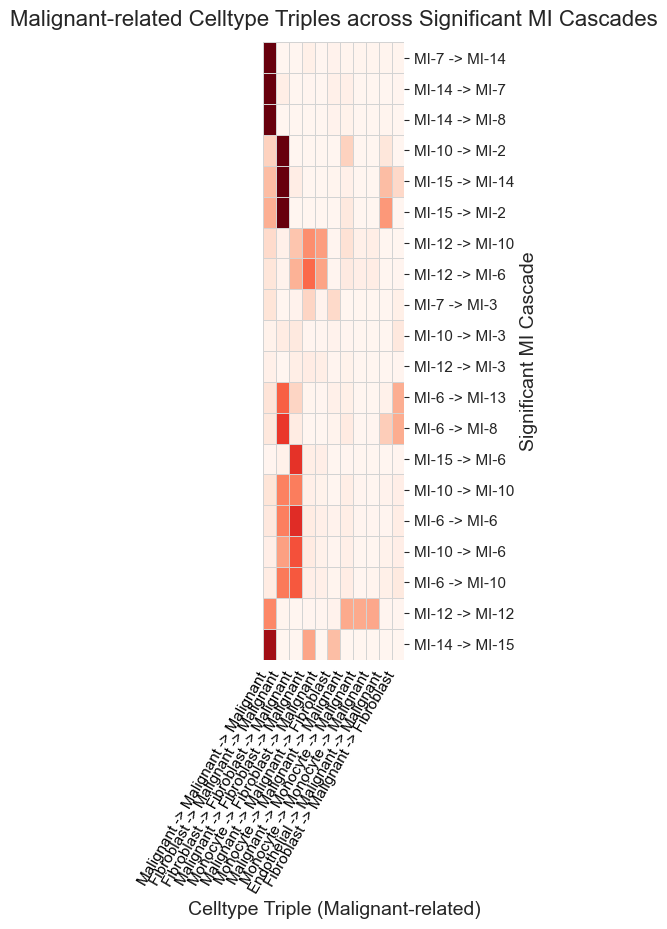

✅ Saved: Heatmap_Average_prop_Celltype_triple_across_MI_cascades_Malignant.png


In [10]:
# ==============================================================
# 1. Heatmap for all celltype triples across all MI cascades
# ==============================================================
plot_heatmap(
    prop_avg_allsample_filter_merge_pivot_select,
    title="Average Proportion of Celltype Triples across MI Cascades",
    xlabel="Celltype Triple",
    ylabel="MI Cascade",
    filename="Heatmap_Average_prop_Celltype_triple_across_MI_cascades.png",
    highlight_malignant=True
)


# ==============================================================
# 2. Heatmap for Malignant-related celltype triples only
# ==============================================================
prop_malignant = prop_avg_allsample_filter_merge_pivot_select.loc[
    prop_avg_allsample_filter_merge_pivot_select.index.str.contains("Malignant")
]

plot_heatmap(
    prop_malignant,
    title="Malignant-related Celltype Triples across Significant MI Cascades",
    xlabel="Celltype Triple (Malignant-related)",
    ylabel="Significant MI Cascade",
    filename="Heatmap_Average_prop_Celltype_triple_across_MI_cascades_Malignant.png"
)

# In-situ Visualization of MI Cascades of interest (cell1-[MI-i]>cell2-[MI-j]>cell3)

In [11]:
print(MI_colocal_summary_significant)

     zscore_countcolocal  pvalue_adjusted  MI_first  MI_second
80              0.949177          0.00002         6          6
82              0.595781          0.00002         6          8
84              0.916288          0.00002         6         10
87              0.674265          0.00002         6         13
92              0.658882          0.00002         7          3
103             0.681107          0.00002         7         14
136             0.588748          0.00002        10          2
137             0.602858          0.00002        10          3
140             0.911136          0.00002        10          6
144             0.818745          0.00002        10         10
167             0.657655          0.00002        12          3
170             0.727718          0.00002        12          6
174             0.616938          0.00002        12         10
176             0.589674          0.00002        12         12
201             0.791730          0.00002        14    

## Specify the upstream and downstream MI of interest, and cell type triple

In [12]:
MI_first_of_interest = 12
MI_second_of_interest = 10
celltype_triple_of_interest = 'Monocyte -> Fibroblast -> Malignant'

In [13]:
search_index = np.where(
    (MI_colocal_summary_significant['MI_first'] == MI_first_of_interest) &
    (MI_colocal_summary_significant['MI_second'] == MI_second_of_interest)
)[0][0]
MI_first_index = int(MI_first_of_interest) - 1
MI_second_index = int(MI_second_of_interest) - 1
ct1_cur = celltype_triple_of_interest.split("->")[0].strip()
ct2_cur = celltype_triple_of_interest.split("->")[1].strip()
ct3_cur = celltype_triple_of_interest.split("->")[2].strip()
celltriple_index_sample_cur = celltriple_index_sample_list[search_index]
print(f"Now showing: {ct1_cur} -> {ct2_cur} -> {ct3_cur}, MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}")


Now showing: Monocyte -> Fibroblast -> Malignant, MI-12 -> MI-10


In [14]:
def safe_filename(name: str) -> str:
    """Replace invalid filename characters."""
    return re.sub(r'[\\/:*?"<>|]', "_", name.replace(" -> ", "-"))

def plot_high_order_MI(
    adata, spatial, celltypes, edge_index, 
    edge_first, edge_second, classes, color_map, 
    sample_index, ct1, ct2, ct3, 
    MI_first_idx, MI_second_idx, MI_first_id, MI_second_id,
    save_dir, triple_name="celltriple"
):
    """Plot spatial MI cascade for (ct1→ct2→ct3) within a sample."""
    # --- set clean white background ---
    plt.style.use("seaborn-v0_8-white")   # white background style
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.set_facecolor("white")             # ensure white canvas
    ax.grid(False)                        # remove grid lines

    # --- 1. plot nodes ---
    for cls in classes:
        idx = celltypes == cls
        if np.any(idx):
            plt.scatter(
                spatial[idx, 0], spatial[idx, 1],
                s=6, c=color_map.get(cls, "gray"),
                label=cls, alpha=1, edgecolors="none"
            )

    # --- 2. plot MI-first edges ---
    for sender, receiver in edge_first:
        x0, y0 = spatial[sender]; x1, y1 = spatial[receiver]
        plt.arrow(
            x0, y0, x1 - x0, y1 - y0,
            length_includes_head=True, lw=1,
            head_width=15, head_length=15,
            fc="#C71E64", ec="#C71E64", alpha=0.6
        )

    # --- 3. plot MI-second edges ---
    for sender, receiver in edge_second:
        x0, y0 = spatial[sender]; x1, y1 = spatial[receiver]
        plt.arrow(
            x0, y0, x1 - x0, y1 - y0,
            length_includes_head=True, lw=1,
            head_width=15, head_length=15,
            fc="#4D2D8C", ec="#4D2D8C", alpha=0.6
        )

    # --- 4. finalize layout ---
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3)
    plt.xlabel("X"); plt.ylabel("Y")
    plt.title(f"{ct1} → {ct2} → {ct3}\n(MI-{MI_first_id} → MI-{MI_second_id})", fontsize=12)
    plt.tight_layout()

    # --- 5. save figure ---
    os.makedirs(os.path.join(save_dir, "Insitu_High_order_MI"), exist_ok=True)
    triple_safe = safe_filename(triple_name)
    base = f"Spatial_{sample_index}_{triple_safe}_MI-{MI_first_id}_MI-{MI_second_id}"
    plt.savefig(os.path.join(save_dir, "Insitu_High_order_MI", base + ".pdf"), dpi=300, facecolor="white")
    plt.savefig(os.path.join(save_dir, "Insitu_High_order_MI", base + ".png"), dpi=300, facecolor="white")
    plt.close()



# ---------- Define color map ----------
classes = np.unique(adata_list[0].obs["cell.types"])
color_map = dict(zip(
    classes,
    ["#1f77b4", "#17becf", "#c49c94", "#b22222",
     "#9467bd", "#ff7f0e", "#2ca02c"]
))

# ==============================================================
# LOOP OVER SAMPLES
# ==============================================================

for sample_index in range(nsample):
    adata_cur = adata_list[sample_index]
    spatial = adata_cur.obsm["spatial"]
    celltypes = adata_cur.obs["cell.types"].values
    edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
    Factor_envir_cur = Factor_envir_list[sample_index]

    # --- extract target triple edges ---
    rel_first = np.where(Factor_envir_cur[:, MI_first_index] > MI_threshold)[0]
    rel_second = np.where(Factor_envir_cur[:, MI_second_index] > MI_threshold)[0]
    edge_first_all = edge_index[rel_first, :]
    edge_second_all = edge_index[rel_second, :]

    # --- select matching triple (ct1→ct2→ct3) ---
    triple_edges = celltriple_index_sample_cur[sample_index]
    triple_ct = adata_cur.obs["cell.types"].values[triple_edges]
    mask = (
        (triple_ct[:, 0] == ct1_cur) &
        (triple_ct[:, 1] == ct2_cur) &
        (triple_ct[:, 2] == ct3_cur)
    )
    triple_edges = triple_edges[mask]

    # split MI-first and MI-second
    edge_first = triple_edges[:, [0, 1]]
    edge_second = triple_edges[:, [1, 2]]

    # --- plot ---
    plot_high_order_MI(
        adata=adata_cur,
        spatial=spatial,
        celltypes=celltypes,
        edge_index=edge_index,
        edge_first=edge_first,
        edge_second=edge_second,
        classes=classes,
        color_map=color_map,
        sample_index=sample_index,
        ct1=ct1_cur, ct2=ct2_cur, ct3=ct3_cur,
        MI_first_idx=MI_first_index,
        MI_second_idx=MI_second_index,
        MI_first_id=MI_first_of_interest,
        MI_second_id=MI_second_of_interest,
        save_dir=file_savepath_main,
        triple_name=f"{ct1_cur} -> {ct2_cur} -> {ct3_cur}"
    )

# Differential Gene, Ligand–Receptor, and Functional State Analysis between Cascaded and Non-Cascaded Triplets

In [15]:
###############################################################
# 1. Initialization and Preprocessing
###############################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import ranksums

# -----------------------------
# Define pathways
# -----------------------------
pathway1_chose, pathway2_chose = ["SPP1"], ["THBS"]
pathway1_chose_merge, pathway2_chose_merge = "+".join(pathway1_chose), "+".join(pathway2_chose)

def expand_genes(genes):
    """Split combined gene symbols like 'COL1A1_COL1A2'"""
    expanded = []
    for g in genes:
        expanded.extend(g.split("_")) if "_" in g else expanded.append(g)
    return np.unique(expanded)

# -----------------------------
# Load LR metadata
# -----------------------------
LR_meta = pd.read_csv(file_savepath_main + "LR_meta_incellchatdb.csv")

def get_pathway_indices(pathway_list):
    idx = np.where(LR_meta['pathway_name'].isin(pathway_list))[0]
    ligands = expand_genes(np.unique(LR_meta.loc[idx, 'ligand']))
    receptors = expand_genes(np.unique(LR_meta.loc[idx, 'receptor']))
    return idx, ligands, receptors

LRindex_pathway1, ligand_pathway1, receptor_pathway1 = get_pathway_indices(pathway1_chose)
LRindex_pathway2, ligand_pathway2, receptor_pathway2 = get_pathway_indices(pathway2_chose)

def get_gene_indices(adata, genes):
    return np.where(np.isin(adata.var_names, genes))[0]

ligand_pathway1_geneindex = get_gene_indices(adata_list[0], ligand_pathway1)
receptor_pathway1_geneindex = get_gene_indices(adata_list[0], receptor_pathway1)
ligand_pathway2_geneindex = get_gene_indices(adata_list[0], ligand_pathway2)
receptor_pathway2_geneindex = get_gene_indices(adata_list[0], receptor_pathway2)

# -----------------------------
# Normalize LR pair matrix
# -----------------------------
cellpair_LRpair_neigh_merge = np.vstack([
    SpiderNet_data_pyg_list[i]['cellpair_LRpair_neigh'].cpu().numpy()
    for i in range(nsample)
])
cellpair_LRpair_neigh_merge_max = np.max(cellpair_LRpair_neigh_merge, axis=0)

# -----------------------------
# Expression data normalization
# -----------------------------
exp_data_all = np.vstack([adata.X.toarray() for adata in adata_list])
exp_data_all_max = np.max(exp_data_all, axis=0)

# -----------------------------
# Determine fibroblast position in triplet
# -----------------------------
fibroblast_relindex_triple = {'Fibroblast': [0, 1, 2][[ct1_cur, ct2_cur, ct3_cur].index('Fibroblast')]} \
    if 'Fibroblast' in [ct1_cur, ct2_cur, ct3_cur] else np.nan


In [16]:
# 2. CAF markers and Functional states
###############################################################
caf_modules = {
    "myCAF": ["ACTA2","TAGLN","MYL9","TPM2","CNN1","CALD1","COL1A1","COL1A2"],
    "iCAF": ["IL6","CXCL12","CXCL14","LIF","CCL2","PTGS2"],
    "apCAF": ["HLA-DRA","HLA-DRB1","CD74","CIITA"],
    "meCAF": ["COL11A1","THBS2","MMP11","ITGA11","FN1","VCAN","SPARC","SULF1","LOX","PLOD2"],
    "periCAF": ["RGS5","PDGFRB","MCAM","NOTCH3","TAGLN"],
    "prolCAF": ["MKI67","TOP2A","PCNA"]
}
caf_genes_inadata = np.unique([g for m in caf_modules.values() for g in m if g in adata_list[0].var_names])
caf_genes_inadata_geneindex = get_gene_indices(adata_list[0], caf_genes_inadata)

# Functional gene sets
func_df = pd.read_csv("D:/CellFlowMap/HGSC/Data/CancerSEA_OV/functional_geneset_list_df.csv")
func_df = func_df[func_df['Gene'].isin(adata_list[0].var_names)]
functional_geneset_choose_geneindex_dict = {
    term: get_gene_indices(adata_list[0], func_df.loc[func_df['GeneSet'] == term, 'Gene'])
    for term in func_df['GeneSet'].unique()
}

In [17]:
###############################################################
# 3. Initialize Analysis Containers
###############################################################
triplet_groups = ["BothPos","OnlyMIfirst","OnlyMIsecond","BothNeg"]
pathways = ["pathway1","pathway2"]

def init_nested_dict(levels, leaf_type=list):
    if len(levels)==1: return {k: leaf_type() for k in levels[0]}
    return {k: init_nested_dict(levels[1:], leaf_type) for k in levels[0]}

LRStrength_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
Ligandexpression_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
Receptorexpression_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
CAFscore_all = {k: [] for k in triplet_groups}
Functionalstate_all = {
    k: {term: [] for term in functional_geneset_choose_geneindex_dict.keys()}
    for k in triplet_groups
}

In [21]:
###############################################################
# 4. Core Analysis Loop
###############################################################
from scipy.spatial.distance import cdist
MI_threshold_use = 0.5

def extract_triplets(F_cut, A, edge_index, cell_types, cond_first, cond_second, ct1, ct2, ct3):
    """Extract valid triplets with matching cell type patterns."""
    r1, r2 = np.where(cond_first)[0], np.where(cond_second)[0]
    A_sel = A[r1, :][:, r2]; rows, cols = A_sel.nonzero()
    pairs = np.vstack([r1[rows], r2[cols]]).T
    triplets = np.hstack([edge_index[pairs[:,0]], edge_index[pairs[:,1],1][:,None]])
    mask = (cell_types[triplets][:,0]==ct1)&(cell_types[triplets][:,1]==ct2)&(cell_types[triplets][:,2]==ct3)
    return triplets[mask]

def get_rel_indices(trip, edge_index, pathway):
    i1,i2=(0,1) if pathway=="pathway1" else (1,2)
    return np.unique([np.where((edge_index[:,0]==t[i1])&(edge_index[:,1]==t[i2]))[0][0]
                      for t in trip if np.any((edge_index[:,0]==t[i1])&(edge_index[:,1]==t[i2]))])

for sample_index, adata in enumerate(adata_list):
    F = (Factor_envir_norm_list[sample_index] > MI_threshold_use).astype(int)
    A = hyper_edge_adj_list[sample_index]
    edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
    cell_types = adata.obs['cell.types'].values
    exp_norm = adata.X.toarray() / (exp_data_all_max + 1e-8)
    lr_norm = SpiderNet_data_pyg_list[sample_index]['cellpair_LRpair_neigh'].cpu().numpy() / (cellpair_LRpair_neigh_merge_max + 1e-8)

    conds = {
        "BothPos": (F[:, MI_first_index]==1, F[:, MI_second_index]==1),
        "OnlyMIfirst": (F[:, MI_first_index]==1, F[:, MI_second_index]==0),
        "OnlyMIsecond": (F[:, MI_first_index]==0, F[:, MI_second_index]==1),
        "BothNeg": (F[:, MI_first_index]==0, F[:, MI_second_index]==0),
    }

    for group, (c1, c2) in conds.items():
        triples = extract_triplets(F, A, edge_index, cell_types, c1, c2, ct1_cur, ct2_cur, ct3_cur)
        rel_p1, rel_p2 = get_rel_indices(triples, edge_index, "pathway1"), get_rel_indices(triples, edge_index, "pathway2")
        fb_idx = edge_index[rel_p1, fibroblast_relindex_triple['Fibroblast']] if len(rel_p1)>0 else np.array([])
        mal_idx = edge_index[rel_p2, 1] if len(rel_p2)>0 else np.array([])

        for p, lr_idx in zip(pathways, [LRindex_pathway1, LRindex_pathway2]):
            rel_idx = rel_p1 if p=="pathway1" else rel_p2
            if len(rel_idx)>0:
                LRStrength_pathwayagg_all[p][group].extend(lr_norm[:,lr_idx].mean(1)[rel_idx].tolist())

        for p, (lig_idx, rec_idx, rel_idx) in zip(
            pathways, [(ligand_pathway1_geneindex, receptor_pathway1_geneindex, rel_p1),
                       (ligand_pathway2_geneindex, receptor_pathway2_geneindex, rel_p2)]
        ):
            if len(rel_idx)==0: continue
            lig_exp = exp_norm[np.unique(edge_index[rel_idx,0]),:][:,lig_idx].mean(1)
            rec_exp = exp_norm[np.unique(edge_index[rel_idx,1]),:][:,rec_idx].mean(1)
            Ligandexpression_pathwayagg_all[p][group].extend(lig_exp.tolist())
            Receptorexpression_pathwayagg_all[p][group].extend(rec_exp.tolist())

        if len(fb_idx)>0:
            CAFscore_all[group].extend(
                exp_norm[fb_idx,:][:,caf_genes_inadata_geneindex].mean(1).tolist()
            )
        for term, idx in functional_geneset_choose_geneindex_dict.items():
            if len(mal_idx)>0:
                Functionalstate_all[group][term].extend(
                    exp_norm[mal_idx,:][:,idx].mean(1).tolist()
                )

In [35]:
###############################################################
# 5. Statistical comparison and visualization
###############################################################
def p_to_star(p): return "****" if p<1e-4 else "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "n.s."

def plot_box(data_dict, ylabel, title_prefix, filename_prefix):
    for p in pathways:
        pname = pathway1_chose_merge if p == "pathway1" else pathway2_chose_merge
        groups_all = {
            "MI cascade": data_dict[p]["BothPos"],
            "MI-first only": data_dict[p]["OnlyMIfirst"],
            "MI-second only": data_dict[p]["OnlyMIsecond"],
            "No MI": data_dict[p]["BothNeg"]
        }

        groups = {
            "MI cascade model": groups_all["MI cascade"],
            "Non-cascaded model": groups_all["MI-second only"]
        }
        tick_labels, data = list(groups.keys()), list(groups.values())
        colors = ["#FFE2E2", "#99DDCC"]

        plt.figure(figsize=(3, 4))
        # ✅ use 'tick_labels' instead of deprecated 'labels'
        box = plt.boxplot(data, tick_labels=tick_labels, patch_artist=True, showfliers=False)
        [b.set_facecolor(c) for b, c in zip(box['boxes'], colors)]

        # Add annotations and style
        plt.ylabel(ylabel, fontsize=12)
        plt.title(f"{title_prefix}: {pname}", fontsize=12)
        ymax = max([max(v) if len(v) > 0 else 0 for v in data]) or 1
        _, pval = ranksums(data[0], data[1], alternative="greater")
        plt.text(1.5, ymax * 1.05, p_to_star(pval), ha="center", fontsize=12)

        plt.tight_layout()
        fname = f"{file_savepath_main}/{p}_{filename_prefix}_{pname}_{ct1_cur}-{ct2_cur}-{ct3_cur}.png"
        plt.savefig(fname, dpi=300)
        plt.show()
        plt.close()


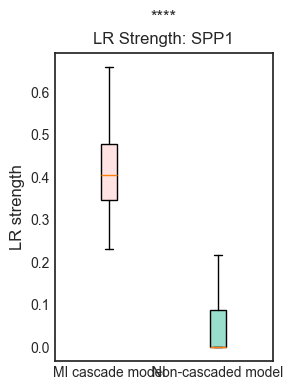

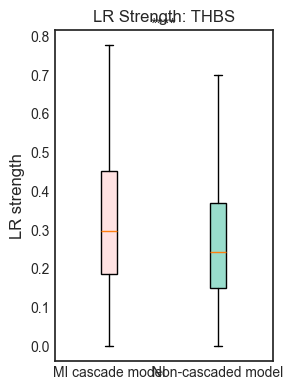

In [36]:
# Plot the ligand-receptor related boxplots
plot_box(LRStrength_pathwayagg_all, "LR strength", "LR Strength", "LRstrength")

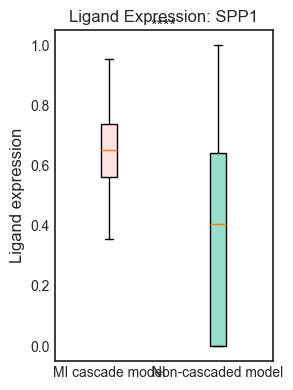

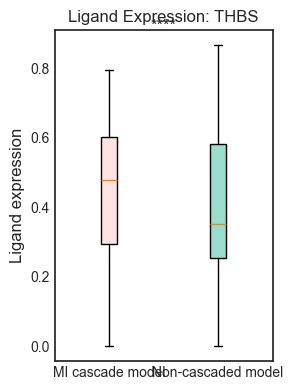

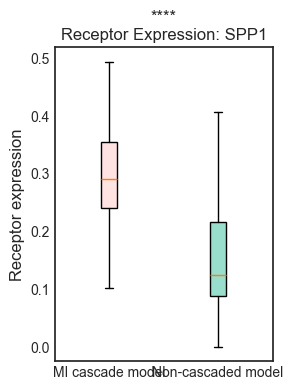

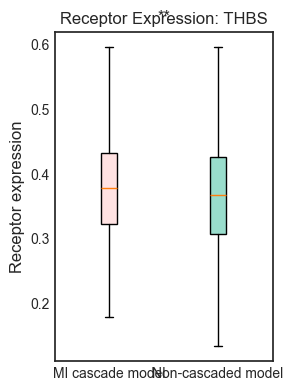

In [37]:
# Plot the ligand and receptor expression boxplots
plot_box(Ligandexpression_pathwayagg_all, "Ligand expression", "Ligand Expression", "Ligand")
plot_box(Receptorexpression_pathwayagg_all, "Receptor expression", "Receptor Expression", "Receptor")

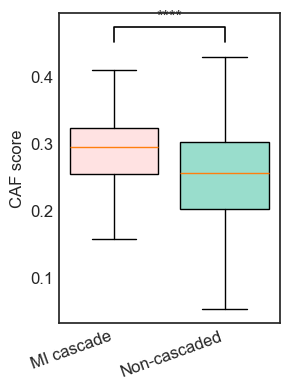

In [38]:
# Plot the CAF score boxplot
plt.figure(figsize=(3, 4))
data = [CAFscore_all["BothPos"], CAFscore_all["OnlyMIsecond"]]
tick_labels = ["MI cascade", "Non-cascaded"]
colors = ["#FFE2E2", "#99DDCC"]

# Draw the boxplot (use 'tick_labels' instead of 'labels' for Matplotlib ≥3.9)
box = plt.boxplot(data, tick_labels=tick_labels, patch_artist=True, showfliers=False, widths=0.8)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add significance annotation
_, pval = ranksums(data[0], data[1], alternative="greater")
ymax = max([max(v) if len(v) > 0 else 0 for v in data]) * 1.05
plt.plot([1, 1, 2, 2], [ymax, ymax * 1.05, ymax * 1.05, ymax], lw=1.2, c="k")
plt.text(1.5, ymax * 1.07, p_to_star(pval), ha="center", fontsize=12)

# Axis labels and layout
plt.ylabel("CAF score", fontsize=12)
plt.xticks(fontsize=12, rotation=20, ha="right")
plt.yticks(fontsize=12)
plt.tight_layout()

# Save and display
plt.savefig(file_savepath_main + f"/CAFscore_{ct1_cur}-{ct2_cur}-{ct3_cur}.png", dpi=300)
plt.show()
plt.close()


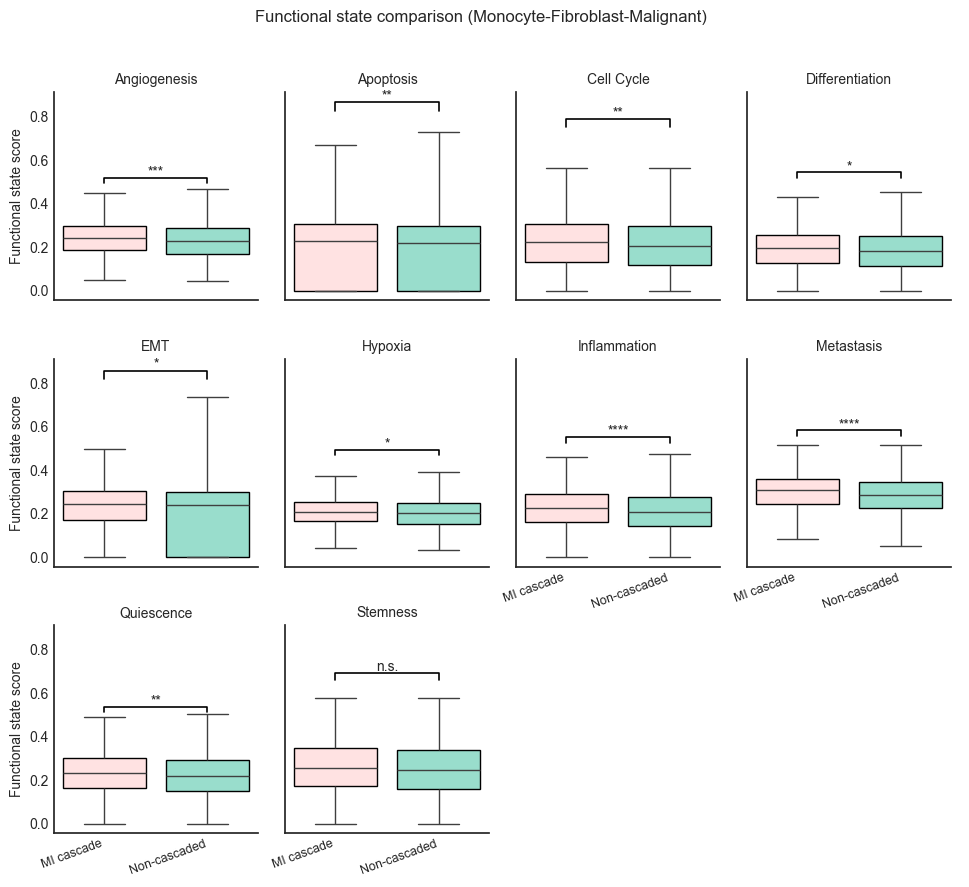

In [39]:
# ============================================
# Plot the functional state boxplots
# ============================================
records = [
    {"group": g, "geneset": gs, "value": v}
    for g, d in Functionalstate_all.items()
    for gs, vals in d.items()
    for v in vals
]
df_plot = pd.DataFrame(records)

# Define order and colors
order = ["BothPos", "OnlyMIsecond"]
pretty_labels = {"BothPos": "MI cascade", "OnlyMIsecond": "Non-cascaded"}
fill_colors = ["#FFE2E2", "#99DDCC"]

# Create facet boxplots per geneset
g = sns.catplot(
    data=df_plot, x="group", y="value", col="geneset",
    kind="box", order=order, showfliers=False,
    col_wrap=4, height=3, aspect=0.8,
    boxprops={'facecolor': 'white', 'edgecolor': 'black'}
)

# Apply consistent colors to all boxes
for ax in g.axes.flatten():
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor(fill_colors[i % len(fill_colors)])

# Perform Wilcoxon tests and annotate stars
for ax, geneset in zip(g.axes.flatten(), df_plot["geneset"].unique()):
    subdf = df_plot[df_plot["geneset"] == geneset]
    vals1 = subdf.loc[subdf["group"] == "BothPos", "value"]
    vals2 = subdf.loc[subdf["group"] == "OnlyMIsecond", "value"]
    if len(vals1) > 0 and len(vals2) > 0:
        _, pval = ranksums(vals1, vals2, alternative="greater")
        stars = p_to_star(pval)
        ymax = subdf["value"].max()
        h = ymax * 0.05
        ax.plot([0, 0, 1, 1], [ymax, ymax + h, ymax + h, ymax], lw=1.2, c="k")
        ax.text(0.5, ymax + h * 1.2, stars, ha="center", fontsize=10)

    # Explicitly set both ticks and labels
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([pretty_labels[o] for o in order],
                       rotation=20, ha="right", fontsize=9)
    ax.set_title(geneset, fontsize=10)


# Set global labels and layout
g.set_axis_labels("", "Functional state score")
g.fig.suptitle(f"Functional state comparison ({ct1_cur}-{ct2_cur}-{ct3_cur})", fontsize=12)
g.fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save and show the figure
save_path = file_savepath_main + f"/Functionalstate_{ct1_cur}-{ct2_cur}-{ct3_cur}_withstats.png"
g.savefig(save_path, dpi=300)
plt.show()
plt.close()
